Clean universe contains 30 securities.


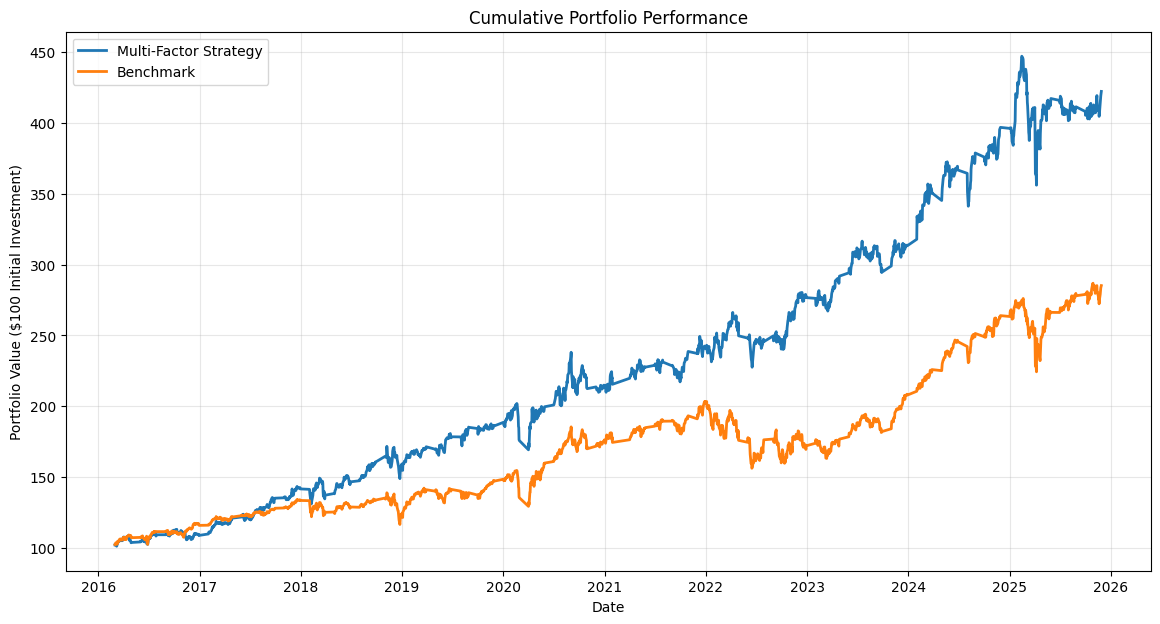

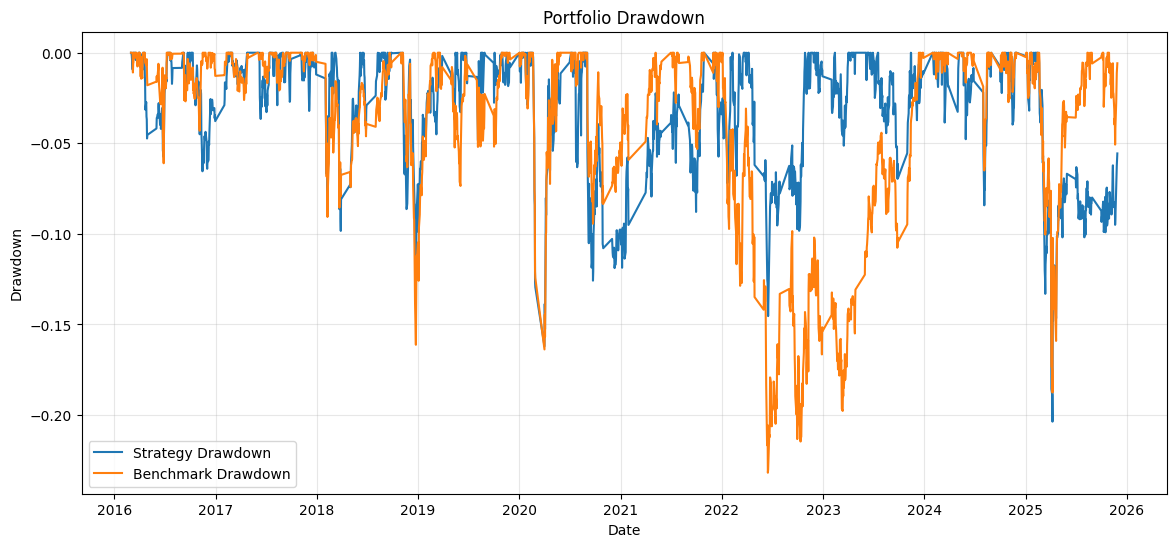

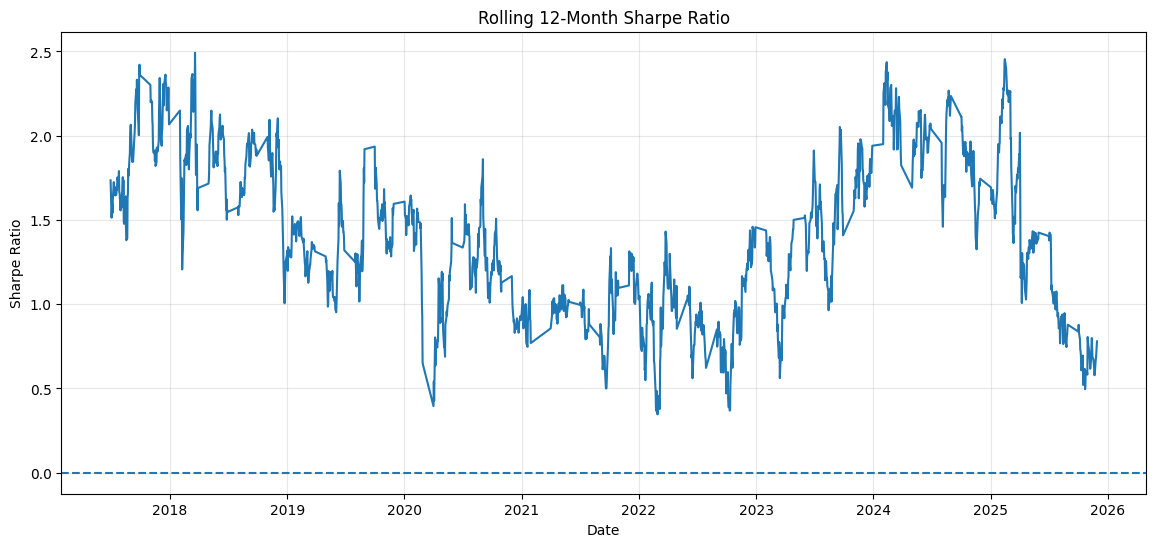

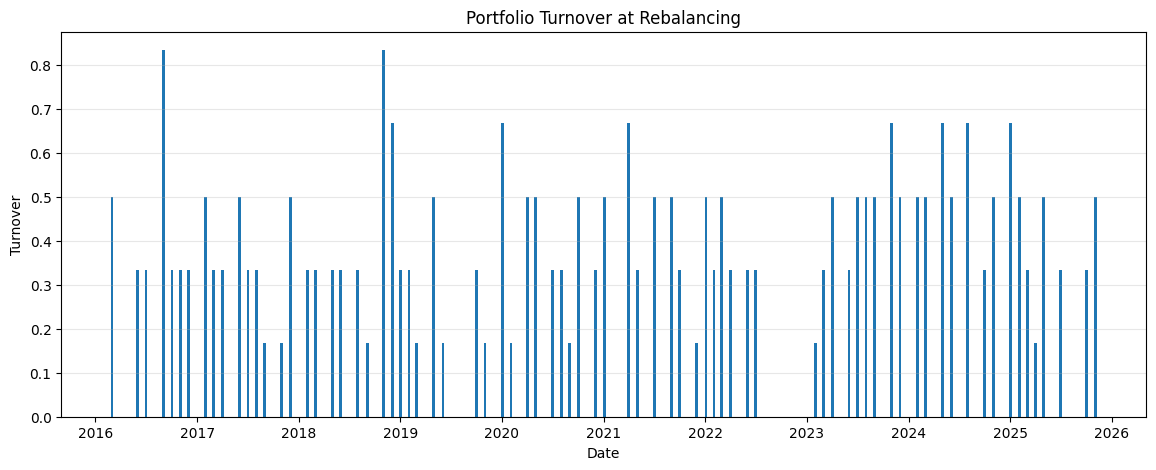

Average portfolio turnover: 37.30%


In [ ]:
# ============================================================
# SECTION 1: ENVIRONMENT SETUP
# ============================================================

!pip -q install yfinance

# ============================================================
# SECTION 2: IMPORTS
# ============================================================

from __future__ import annotations

import logging
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# ============================================================
# SECTION 3: PROJECT CONFIGURATION
# ============================================================

@dataclass
class StrategyConfig:
    """
    Central configuration for the quantitative factor strategy.

    Keeping parameters in one object makes experiments
    reproducible and reduces hard-coded values throughout
    the research pipeline.
    """

    start_date: str = "2015-01-01"
    end_date: str = "2025-12-31"

    benchmark: str = "SPY"

    momentum_lookback: int = 252
    momentum_skip: int = 21

    volatility_lookback: int = 63

    top_fraction: float = 0.20

    rebalance_frequency: str = "ME"

    transaction_cost: float = 0.001

    momentum_weight: float = 0.60
    volatility_weight: float = 0.40


config = StrategyConfig()

# ============================================================
# SECTION 4: INVESTMENT UNIVERSE
# ============================================================

TICKERS = [
    "AAPL", "MSFT", "AMZN", "NVDA", "GOOGL",
    "META", "JPM", "BAC", "JNJ", "XOM",
    "PG", "KO", "PEP", "WMT", "HD",
    "DIS", "NFLX", "INTC", "CSCO", "V",
    "MA", "UNH", "ABBV", "MRK", "CVX",
    "ADBE", "CRM", "AMD", "QCOM", "ORCL"
]

# ============================================================
# SECTION 5: DATA COLLECTION PIPELINE
# ============================================================

def download_price_data(
    tickers: List[str],
    start: str,
    end: str
) -> pd.DataFrame:
    """
    Download adjusted historical prices.

    Parameters
    ----------
    tickers:
        Securities to download.

    start:
        Historical start date.

    end:
        Historical end date.

    Returns
    -------
    pd.DataFrame
        Adjusted closing prices indexed by date.
    """

    if not tickers:
        raise ValueError("Ticker list is empty.")

    try:

        data = yf.download(
            tickers=tickers,
            start=start,
            end=end,
            auto_adjust=True,
            progress=False,
            threads=True
        )

    except Exception as exc:

        raise RuntimeError(
            "Market data download failed. "
            "Check your internet connection and ticker symbols."
        ) from exc

    if data.empty:

        raise ValueError(
            "Downloaded dataset is empty."
        )

    if isinstance(data.columns, pd.MultiIndex):

        if "Close" not in data.columns.get_level_values(0):

            raise ValueError(
                "Expected adjusted price data was not returned."
            )

        prices = data["Close"]

    else:

        prices = data["Close"].to_frame()

    return prices


prices = download_price_data(
    TICKERS,
    config.start_date,
    config.end_date
)

benchmark_prices = download_price_data(
    [config.benchmark],
    config.start_date,
    config.end_date
)

prices.head()

# ============================================================
# SECTION 6: DATA VALIDATION AND CLEANING
# ============================================================

def clean_price_data(
    prices: pd.DataFrame,
    max_missing_fraction: float = 0.05,
    min_assets: int = 1
) -> pd.DataFrame:
    """
    Clean price data and remove securities with excessive
    missing observations.
    """

    if prices.empty:
        raise ValueError(
            "Cannot clean an empty price dataset."
        )

    prices = prices.copy()

    # Remove duplicate dates.
    prices = prices[
        ~prices.index.duplicated(keep="first")
    ]

    # Calculate the proportion of missing data for each asset.
    missing_fraction = prices.isna().mean()

    # Keep only assets with an acceptable amount of missing data.
    valid_columns = missing_fraction[
        missing_fraction <= max_missing_fraction
    ].index

    prices = prices[valid_columns]

    # Forward fill small gaps only.
    prices = prices.ffill(limit=5)

    # Remove any remaining incomplete rows.
    prices = prices.dropna(how="any")

    # Check that enough assets remain.
    if prices.shape[1] < min_assets:
        raise ValueError(
            f"Too few valid securities remain after cleaning. "
            f"Expected at least {min_assets}, "
            f"but found {prices.shape[1]}."
        )

    return prices


# Clean the stock universe.
prices = clean_price_data(
    prices,
    min_assets=5
)

# Clean the benchmark.
benchmark_prices = clean_price_data(
    benchmark_prices,
    max_missing_fraction=0.10,
    min_assets=1
)

print(
    f"Clean universe contains "
    f"{prices.shape[1]} securities."
)

# ============================================================
# SECTION 7: RETURN CALCULATION
# ============================================================

returns = prices.pct_change().dropna()

benchmark_returns = (
    benchmark_prices
    .iloc[:, 0]
    .pct_change()
    .dropna()
)

# ============================================================
# SECTION 8: FACTOR ENGINEERING
# ============================================================

def calculate_momentum(
    prices: pd.DataFrame,
    lookback: int,
    skip_recent: int
) -> pd.DataFrame:
    """
    Calculate momentum while excluding the most recent period.

    This approximates the common academic approach of using
    medium-term momentum while reducing short-term reversal
    effects.
    """

    past_price = prices.shift(lookback)

    recent_reference = prices.shift(skip_recent)

    momentum = (
        recent_reference / past_price
    ) - 1

    return momentum


def calculate_volatility(
    returns: pd.DataFrame,
    window: int
) -> pd.DataFrame:
    """
    Calculate annualised rolling realised volatility.
    """

    volatility = (
        returns
        .rolling(window)
        .std()
        * np.sqrt(252)
    )

    return volatility


momentum = calculate_momentum(
    prices,
    config.momentum_lookback,
    config.momentum_skip
)

volatility = calculate_volatility(
    returns,
    config.volatility_lookback
)

# ============================================================
# SECTION 9: CROSS-SECTIONAL FACTOR RANKING
# ============================================================

def percentile_rank(
    factor: pd.DataFrame,
    ascending: bool = True
) -> pd.DataFrame:
    """
    Convert factor values into cross-sectional percentile ranks.

    Ranking makes factors comparable despite different units.
    """

    return factor.rank(
        axis=1,
        pct=True,
        ascending=ascending
    )


momentum_score = percentile_rank(
    momentum,
    ascending=True
)

volatility_score = percentile_rank(
    volatility,
    ascending=False
)

# ============================================================
# SECTION 10: MULTI-FACTOR COMPOSITE SIGNAL
# ============================================================

composite_score = (
    config.momentum_weight
    * momentum_score
    +
    config.volatility_weight
    * volatility_score
)

composite_score.head()

# ============================================================
# SECTION 11: REBALANCING SCHEDULE
# ============================================================

rebalance_dates = (
    composite_score
    .resample(config.rebalance_frequency)
    .last()
    .dropna(how="all")
    .index
)

# ============================================================
# SECTION 12: PORTFOLIO CONSTRUCTION
# ============================================================

def build_portfolio_weights(
    scores: pd.Series,
    top_fraction: float
) -> pd.Series:
    """
    Select top-ranked securities and allocate equally.

    Securities with missing factor scores are excluded.
    """

    scores = scores.dropna()

    if scores.empty:

        return pd.Series(
            dtype=float
        )

    n_assets = max(
        1,
        int(
            np.ceil(
                len(scores)
                * top_fraction
            )
        )
    )

    selected = (
        scores
        .sort_values(
            ascending=False
        )
        .head(n_assets)
        .index
    )

    weights = pd.Series(
        0.0,
        index=scores.index
    )

    weights.loc[selected] = (
        1.0 / n_assets
    )

    return weights


    # ============================================================
# SECTION 13: WALK-FORWARD BACKTEST ENGINE
# ============================================================

def run_backtest(
    returns: pd.DataFrame,
    scores: pd.DataFrame,
    rebalance_dates: pd.DatetimeIndex,
    top_fraction: float,
    transaction_cost: float
) -> Tuple[pd.Series, pd.DataFrame, pd.Series]:
    """
    Run a walk-forward portfolio backtest.

    Portfolio weights are determined using information available
    at the rebalance date and applied to future returns.

    Transaction costs are charged when portfolio turnover occurs.
    """

    strategy_returns = pd.Series(
        index=returns.index,
        dtype=float
    )

    turnover_series = pd.Series(
        index=returns.index,
        dtype=float
    )

    weight_history = {}

    previous_weights = pd.Series(
        0.0,
        index=returns.columns
    )

    for i, rebalance_date in enumerate(rebalance_dates):

        if rebalance_date not in scores.index:

            continue

        current_scores = (
            scores
            .loc[rebalance_date]
            .reindex(
                returns.columns
            )
        )

        current_weights = (
            build_portfolio_weights(
                current_scores,
                top_fraction
            )
            .reindex(
                returns.columns,
                fill_value=0.0
            )
        )

        turnover = (
            0.5
            * np.abs(
                current_weights
                -
                previous_weights
            ).sum()
        )

        start_date = (
            rebalance_date
        )

        if i < len(rebalance_dates) - 1:

            end_date = (
                rebalance_dates[i + 1]
            )

            holding_dates = returns.loc[
                (
                    returns.index
                    > start_date
                )
                &
                (
                    returns.index
                    <= end_date
                )
            ].index

        else:

            holding_dates = returns.loc[
                returns.index
                > start_date
            ].index

        if len(holding_dates) == 0:

            continue

        portfolio_period_returns = (
            returns
            .loc[holding_dates]
            .mul(
                current_weights,
                axis=1
            )
            .sum(axis=1)
        )

        # Apply transaction costs once on the first trading day
        # after rebalancing.

        portfolio_period_returns.iloc[0] -= (
            turnover
            * transaction_cost
        )

        strategy_returns.loc[
            holding_dates
        ] = portfolio_period_returns

        turnover_series.loc[
            holding_dates[0]
        ] = turnover

        weight_history[
            rebalance_date
        ] = current_weights

        previous_weights = current_weights

    weight_history_df = (
        pd.DataFrame(
            weight_history
        ).T
    )

    return (
        strategy_returns.dropna(),
        weight_history_df,
        turnover_series.dropna()
    )

    # ============================================================
# SECTION 14: EXECUTE BACKTEST
# ============================================================

strategy_returns, weight_history, turnover = (
    run_backtest(
        returns=returns,
        scores=composite_score,
        rebalance_dates=rebalance_dates,
        top_fraction=config.top_fraction,
        transaction_cost=config.transaction_cost
    )
)

strategy_returns.head()


# ============================================================
# SECTION 15: BENCHMARK ALIGNMENT
# ============================================================

benchmark_returns = (
    benchmark_returns
    .reindex(strategy_returns.index)
    .dropna()
)

strategy_returns = (
    strategy_returns
    .reindex(benchmark_returns.index)
    .dropna()
)


# ============================================================
# SECTION 16: PERFORMANCE ANALYTICS
# ============================================================

def calculate_performance_metrics(
    returns: pd.Series,
    benchmark: Optional[pd.Series] = None,
    risk_free_rate: float = 0.0
) -> Dict[str, float]:
    """
    Calculate standard portfolio performance metrics.
    """

    returns = returns.dropna()

    if len(returns) < 2:

        raise ValueError(
            "Insufficient return observations."
        )

    trading_days = 252

    cumulative_value = (
        1 + returns
    ).cumprod()

    total_return = (
        cumulative_value.iloc[-1]
        - 1
    )

    years = (
        len(returns)
        / trading_days
    )

    cagr = (
        cumulative_value.iloc[-1]
        ** (1 / years)
        - 1
    )

    annual_volatility = (
        returns.std()
        * np.sqrt(trading_days)
    )

    annual_return = (
        returns.mean()
        * trading_days
    )

    sharpe = np.nan

    if annual_volatility > 0:

        sharpe = (
            annual_return
            - risk_free_rate
        ) / annual_volatility

    running_max = (
        cumulative_value.cummax()
    )

    drawdown = (
        cumulative_value
        / running_max
        - 1
    )

    max_drawdown = (
        drawdown.min()
    )

    metrics = {

        "Total Return":
            total_return,

        "CAGR":
            cagr,

        "Annual Volatility":
            annual_volatility,

        "Sharpe Ratio":
            sharpe,

        "Maximum Drawdown":
            max_drawdown
    }

    if benchmark is not None:

        aligned = pd.concat(
            [
                returns.rename("strategy"),
                benchmark.rename("benchmark")
            ],
            axis=1
        ).dropna()

        if len(aligned) > 10:

            beta = (
                aligned["strategy"]
                .cov(
                    aligned["benchmark"]
                )
                /
                aligned["benchmark"]
                .var()
            )

            benchmark_annual = (
                aligned["benchmark"]
                .mean()
                * trading_days
            )

            alpha = (
                annual_return
                -
                (
                    risk_free_rate
                    +
                    beta
                    * (
                        benchmark_annual
                        - risk_free_rate
                    )
                )
            )

            metrics["Beta"] = beta
            metrics["Alpha"] = alpha

    return metrics


strategy_metrics = (
    calculate_performance_metrics(
        strategy_returns,
        benchmark_returns
    )
)

benchmark_metrics = (
    calculate_performance_metrics(
        benchmark_returns
    )
)

performance_table = pd.DataFrame(
    {
        "Strategy":
            strategy_metrics,

        "Benchmark":
            benchmark_metrics
    }
)

performance_table


# ============================================================
# SECTION 17: CUMULATIVE PERFORMANCE VISUALISATION
# ============================================================

strategy_equity = (
    100
    * (
        1
        + strategy_returns
    ).cumprod()
)

benchmark_equity = (
    100
    * (
        1
        + benchmark_returns
    ).cumprod()
)

plt.figure(
    figsize=(14, 7)
)

plt.plot(
    strategy_equity,
    label="Multi-Factor Strategy",
    linewidth=2
)

plt.plot(
    benchmark_equity,
    label="Benchmark",
    linewidth=2
)

plt.title(
    "Cumulative Portfolio Performance"
)

plt.xlabel("Date")

plt.ylabel(
    "Portfolio Value ($100 Initial Investment)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

# ============================================================
# SECTION 18: DRAWDOWN ANALYSIS
# ============================================================

strategy_drawdown = (
    strategy_equity
    /
    strategy_equity.cummax()
    - 1
)

benchmark_drawdown = (
    benchmark_equity
    /
    benchmark_equity.cummax()
    - 1
)

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    strategy_drawdown,
    label="Strategy Drawdown"
)

plt.plot(
    benchmark_drawdown,
    label="Benchmark Drawdown"
)

plt.title(
    "Portfolio Drawdown"
)

plt.xlabel("Date")

plt.ylabel("Drawdown")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# SECTION 19: ROLLING SHARPE RATIO
# ============================================================

rolling_window = 252

rolling_sharpe = (
    strategy_returns
    .rolling(rolling_window)
    .mean()
    /
    strategy_returns
    .rolling(rolling_window)
    .std()
    * np.sqrt(252)
)

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    rolling_sharpe
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Rolling 12-Month Sharpe Ratio"
)

plt.xlabel("Date")

plt.ylabel(
    "Sharpe Ratio"
)

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# SECTION 20: PORTFOLIO TURNOVER
# ============================================================

plt.figure(
    figsize=(14, 5)
)

plt.bar(
    turnover.index,
    turnover.values,
    width=10
)

plt.title(
    "Portfolio Turnover at Rebalancing"
)

plt.xlabel("Date")

plt.ylabel("Turnover")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

print(
    "Average portfolio turnover:",
    f"{turnover.mean():.2%}"
)